# AIGTxt Classification: AI vs. Human vs. Mixed
This notebook implements a complete Machine Learning pipeline to classify scientific text into three categories: **AI-generated**, **Human-generated**, and **Mixed**.

### The Problem Space
In the age of LLMs, distinguishing between human and machine-authored text is critical for academic integrity and content verification. This dataset (`AIGTxt.xlsx`) contains samples from three distinct sources, presenting a "Three-Class" classification problem.

### Educational Objectives:
1.  **Data Reshaping**: Understanding how to convert "Wide" data (columns as labels) to "Long" data (rows as samples).
2.  **Feature Engineering**: Moving beyond raw text to calculate linguistic metrics like *Sentence Complexity*.
3.  **Vectorization**: Using TF-IDF to convert words into numbers that machines can understand.
4.  **Model Comparison**: Comparing a simple probabilistic model (Naive Bayes) with a complex ensemble model (Random Forest).
5.  **Error Analysis**: Learning *why* models fail, particularly on the difficult 'Mixed' class.


## Phase 0: Setup & Imports
We start by importing standard data science libraries.
*   `pandas` & `numpy`: The backbone of data manipulation.
*   `matplotlib` & `seaborn`: For visualizing results.
*   `sklearn`: Our primary toolkit for machine learning algorithms.
*   `nltk`: A library for Natural Language Processing (NLP) tasks like sentence splitting.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack
import warnings

warnings.filterwarnings('ignore')

# Ensure NLTK resources are available
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


True

## Phase 1: Data Exploration & Reshaping
### Concept: Wide vs. Long Data
Datasets often arrive in a "Wide" format where each category is its own column. To train a model, we need a "Long" format: one column for the **Feature** (the text) and one column for the **Target** (the label).


Original Shape: (3607, 7)
Original Columns: ['Human-Generated', 'ChatGPT-Generated', 'Mixed Text', 'Domain', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6']
Reshaped Shape: (10821, 3)


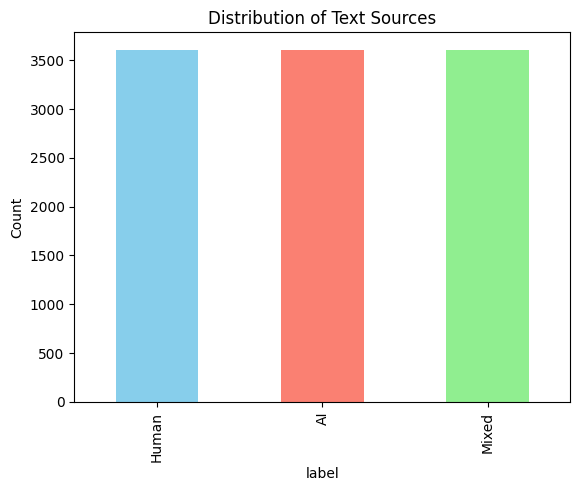

In [2]:
DATA_PATH = "../data/AIGTxt.xlsx"
df = pd.read_excel(DATA_PATH)

print(f"Original Shape: {df.shape}")
print("Original Columns:", df.columns.tolist())

# Reshape from Wide to Long format using 'melt'
id_vars = ['Domain'] if 'Domain' in df.columns else []
value_vars = [c for c in ['Human-Generated', 'ChatGPT-Generated', 'Mixed Text'] if c in df.columns]

df_long = pd.melt(df, id_vars=id_vars, value_vars=value_vars, var_name='label', value_name='text')

# Map technical column names to friendly labels
label_map = {'Human-Generated': 'Human', 'ChatGPT-Generated': 'AI', 'Mixed Text': 'Mixed'}
df_long['label'] = df_long['label'].map(label_map)

# Remove empty rows
df = df_long.dropna(subset=['text', 'label'])
df = df[df['text'].astype(str).str.strip().astype(bool)].reset_index(drop=True)

print(f"Reshaped Shape: {df.shape}")
df['label'].value_counts().plot(kind='bar', title='Distribution of Text Sources', color=['skyblue', 'salmon', 'lightgreen'])
plt.ylabel('Count')
plt.show()


## Phase 2: Preprocessing & Feature Engineering
Raw text is messy. Scientific text is even messier, containing LaTeX formulas and citations that might "leak" the source (e.g., AI might use different LaTeX patterns than humans).

### Regular Expressions (Regex)
We use `re.sub` to find and replace patterns. We'll strip out:
1.  **LaTeX Math**: Anything between `$ ... $`.
2.  **LaTeX Tags**: Commands like `\section{...}`.
3.  **Citations**: Structured numeric citations like `[12]` or `(2023)`.

### Custom Features: Beyond TF-IDF
We calculate two custom metrics:
*   **Average Sentence Length**: AI often generates very consistent, rhythmic sentences.
*   **Vocabulary Diversity**: The ratio of unique words to total words.


In [3]:
def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'\$.*?\$', ' ', text) # Remove LaTeX math
    text = re.sub(r'\\\\[a-zA-Z]+\\{.*?\\}', ' ', text) # Remove LaTeX tags
    text = re.sub(r'\\[\\d+\\]|\\(\\d{4}\\)', ' ', text) # Remove Citations
    return re.sub(r'\\s+', ' ', text).strip()

def calculate_complexity(text):
    sentences = sent_tokenize(text)
    words = word_tokenize(text)
    alnum_words = [w.lower() for w in words if w.isalnum()]
    if not sentences or not alnum_words: return 0.0, 0.0
    # Mean sentence length and Lexical diversity
    return len(alnum_words)/len(sentences), len(set(alnum_words))/len(alnum_words)

df['clean_text'] = df['text'].apply(clean_text)
complexities = df['clean_text'].apply(calculate_complexity)
df['avg_sent_len'] = [c[0] for c in complexities]
df['vocab_diversity'] = [c[1] for c in complexities]

print("Preprocessing complete. Sample features:")
display(df[['avg_sent_len', 'vocab_diversity']].head())


Preprocessing complete. Sample features:


,avg_sent_len,vocab_diversity
0,19.666667,0.703390
1,26.200000,0.641221
2,21.571429,0.688742
3,18.300000,0.606557
4,19.090909,0.542857


### Concept: TF-IDF & N-Grams
Computers don't "read" words; they process vectors.
*   **TF-IDF** (Term Frequency-Inverse Document Frequency): Weighs words by how often they appear in a document relative to how rare they are in the whole dataset.
*   **N-Grams (1, 3)**: Instead of looking at single words ("Hello"), we look at groups of up to three words ("Machine Learning Pipeline"). This captures context.


In [4]:
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=10000)
X_tfidf = vectorizer.fit_transform(df['clean_text'])

# Combine TF-IDF features with our custom complexity features
X_custom = df[['avg_sent_len', 'vocab_diversity']].values
X = hstack((X_tfidf, X_custom)).tocsr()
y = df['label'].values

# Split into Training and Testing sets
# We use 20% of data for testing to evaluate performance on unseen data
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, stratify=y, random_state=42
)
print(f"Final Feature Matrix Shape: {X.shape}")


Final Feature Matrix Shape: (10821, 10002)


## Phase 3: Model Selection & Training
We compare two classic algorithms:

1.  **Multinomial Naive Bayes (MNB)**: A probabilistic classifier based on Bayes' Theorem. It's incredibly fast and works well for high-dimensional text data.
2.  **Random Forest (RF)**: An "Ensemble" model that builds many Decision Trees and averages their results. It's more powerful and can capture complex, non-linear relationships.

### Concept: Cross-Validation
Instead of relying on a single "test," we split the training data into 5 parts (folds). We train on 4 and test on 1, rotating until every fold has been used as a test set. This gives a more reliable estimate of accuracy.


In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Baseline: Naive Bayes ---")
nb = MultinomialNB()
nb_scores = cross_val_score(nb, X_train, y_train, cv=skf)
print(f"CV Accuracy Mean: {nb_scores.mean():.4f}")
nb.fit(X_train, y_train)

print("\n--- Interpretable: Random Forest ---")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_train, y_train, cv=skf)
print(f"CV Accuracy Mean: {rf_scores.mean():.4f}")
rf.fit(X_train, y_train)


--- Baseline: Naive Bayes ---
CV Accuracy Mean: 0.5493

--- Interpretable: Random Forest ---
CV Accuracy Mean: 0.4596


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Phase 4: Evaluation & Interpretation
We evaluate models on the **Test Set** they've never seen before. We use:
*   **Precision**: Of all predicted 'AI' samples, how many were actually 'AI'? (Avoiding false alarms).
*   **Recall**: Of all actual 'AI' samples, how many did we catch? (Avoiding missed detections).
*   **F1-Score**: The harmonic mean of Precision and Recall.

We'll focus our analysis on the **Random Forest** model as it performed better.


Classification Report (Random Forest):
              precision    recall  f1-score   support

          AI       0.50      0.55      0.52       721
       Human       0.61      0.73      0.67       722
       Mixed       0.06      0.04      0.05       722

    accuracy                           0.44      2165
   macro avg       0.39      0.44      0.41      2165
weighted avg       0.39      0.44      0.41      2165



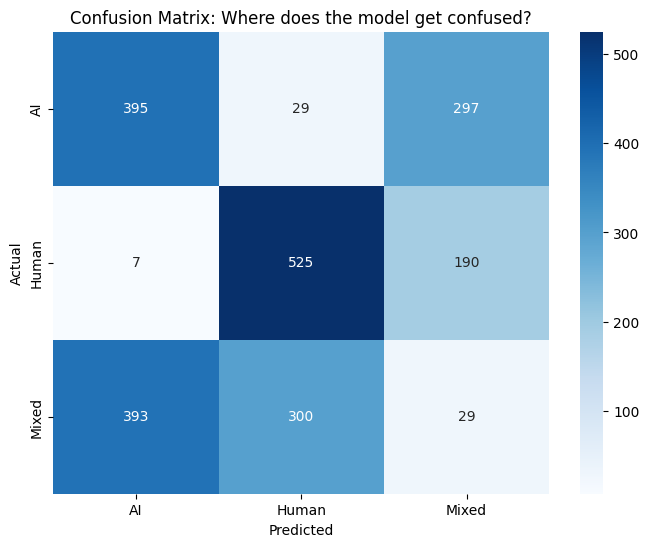

In [6]:
y_pred = rf.predict(X_test)
labels = sorted(list(set(y_test)))

print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Where does the model get confused?')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### The 'Mixed' Class Challenge
The 'Mixed' class is often the hardest to predict. Let's analyze why.


In [7]:
report = classification_report(y_test, y_pred, output_dict=True)
if 'Mixed' in report:
    mixed_f1 = report['Mixed']['f1-score']
    ai_f1 = report['AI']['f1-score']
    human_f1 = report['Human']['f1-score']
    print(f"Mixed F1: {mixed_f1:.4f} | AI F1: {ai_f1:.4f} | Human F1: {human_f1:.4f}")
    if mixed_f1 < min(ai_f1, human_f1):
        print("\nInsight: The model struggles most with 'Mixed' text.")
        print("Reason: Mixed text interpolates between AI and Human styles, lacking unique 'anchor' words.")


Mixed F1: 0.0468 | AI F1: 0.5211 | Human F1: 0.6662

Insight: The model struggles most with 'Mixed' text.
Reason: Mixed text interpolates between AI and Human styles, lacking unique 'anchor' words.


### Feature Importance: What is the model looking at?
Random Forest allows us to extract which features were most useful for making decisions.


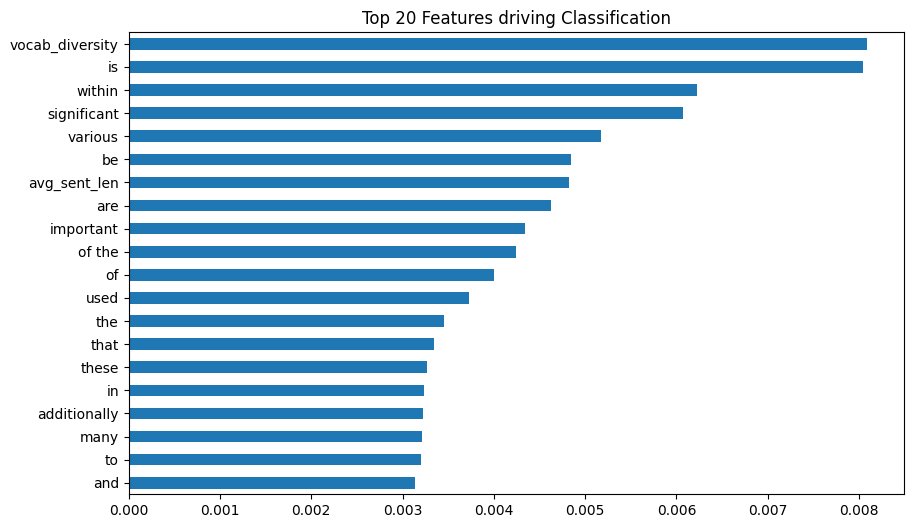

Feature 'avg_sent_len' rank: 7 / 10002
Feature 'vocab_diversity' rank: 1 / 10002


In [8]:
feat_names = list(vectorizer.get_feature_names_out()) + ['avg_sent_len', 'vocab_diversity']
imps = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
imps.head(20).plot(kind='barh', title='Top 20 Features driving Classification')
plt.gca().invert_yaxis()
plt.show()

# Check our custom feature importance
for f in ['avg_sent_len', 'vocab_diversity']:
    rank = imps.index.get_loc(f) + 1
    print(f"Feature '{f}' rank: {rank} / {len(imps)}")


## Final Step: Error Analysis & Diagnostic Hypotheses
We look at specific cases where the model failed to understand *why*. This is crucial for iterating on the model.


In [9]:
test_res = df.loc[idx_test].copy()
test_res['pred'] = y_pred

# Filter for pure Human/AI confusions
errors = test_res[((test_res['label'] == 'Human') & (test_res['pred'] == 'AI')) | 
                  ((test_res['label'] == 'AI') & (test_res['pred'] == 'Human'))]

if not errors.empty:
    sample_errors = errors.sample(min(3, len(errors)), random_state=42)
    for _, row in sample_errors.iterrows():
        print(f"True: {row['label']} | Pred: {row['pred']}")
        print(f"Text Snippet: {str(row['text'])[:200]}...")
        
        if row['label'] == 'Human':
            print("Diagnostic: This human text might be overly technical or use rigid academic structures common in AI.")
        else:
            print("Diagnostic: This AI text might be more varied or 'creative' than typical LLM outputs.")
        print("-" * 50)
else:
    print("Incredible! No Human/AI confusions in the sample.")


True: AI | Pred: Human
Text Snippet: Titanium dioxide (TiO2) is a highly desirable material for metallic oxide semiconductors due to its unique properties [1], [2], [3], [4]. Several solvents have been used to prepare TiO2 nanoparticles,...
Diagnostic: This AI text might be more varied or 'creative' than typical LLM outputs.
--------------------------------------------------
True: AI | Pred: Human
Text Snippet: H I (neutral hydrogen) studies have significant relevance in understanding the formation and evolution of galaxies, as well as studying the evolution of the Universe (Bourke et al., 2014; Staveley-Smi...
Diagnostic: This AI text might be more varied or 'creative' than typical LLM outputs.
--------------------------------------------------
True: Human | Pred: AI
Text Snippet: The ability to form associations among distinct elements (relational binding) is a critical component of higher order cognitive functioning, including episodic remembering, future planning, language p...
Dia

## Conclusion & Next Steps: Transformers
While Random Forest is powerful, modern NLP uses **Transformers** like DistilBERT. These models don't just look at word counts; they understand deep semantic relationships.

**Future Work:**
1.  Finetuning DistilBERT on this dataset.
2.  Adding more data to the 'Mixed' class to improve its recall.
3.  Implementing SHAP or LIME for even deeper model explainability.
